## Inference test

In [1]:
model_name = "digitrec-serve"

In [ ]:
!kubectl get pods | grep digitrec

digitrec-serve-predictor-00001-deployment-7575ccbf4b-nstfc   2/2     Running     0          23s


In [3]:
!kubectl get inferenceservices | grep {model_name}

digitrec-serve   https://digitrec-serve-predictor-ashish-kumarj-h-653cd6af.ingress.pcai.hpelabs.co.il   True           100                              digitrec-serve-predictor-00001   25s


In [ ]:
%%capture cmd_output
!kubectl get inferenceservices | grep digitrec | awk '{print $2}'

In [5]:
serving_endpoint = cmd_output.stdout[:-2]
print(f"Endpoint address: {serving_endpoint}")

Endpoint address: https://digitrec-serve-predictor-ashish-kumarj-h-653cd6af.ingress.pcai.hpelabs.co.il


## KServe server responding test

In [6]:
import requests
import sys
session = requests.Session()

In [7]:
inference_url = f"{serving_endpoint}/v1/models/{model_name}"
print(f"Inference URL: {inference_url}")

Inference URL: https://digitrec-serve-predictor-ashish-kumarj-h-653cd6af.ingress.pcai.hpelabs.co.il/v1/models/digitrec-serve


In [8]:
#!curl https://digitrec-serve-predictor-christian-temporale-hpe-com-4bdac2aa.prod.discover.hpepcai.com/v1/models/digitrec-serve

In [9]:
#skip proxy
ipaddr = "digitrec-serve-predictor-00001-deployment-7448f476d9-6shtm"
os.environ['NO_PROXY'] = f"{ipaddr}"

# Build HTTP request
response = requests.get(inference_url, verify=False)

print("\nResponse:\n" + response.content.decode("utf-8"))


Response:
{
 "model_version_status": [
  {
   "version": "1",
   "state": "AVAILABLE",
   "status": {
    "error_code": "OK",
    "error_message": ""
   }
  }
 ]
}



/opt/conda/lib/python3.11/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'digitrec-serve-predictor-ashish-kumarj-h-653cd6af.ingress.pcai.hpelabs.co.il'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


## KServe inference test

In [10]:
import kfp
from pathlib import Path
kfp_client = kfp.Client()
user_mounted_dir_name = kfp_client.get_user_namespace()
user_shared_dir = f"{str(Path.home())}/{user_mounted_dir_name}/"
training_data_dir = user_shared_dir + "training/"

/opt/conda/lib/python3.11/site-packages/kfp/client/client.py:159: FutureWarning: This client only works with Kubeflow Pipeline v2.0.0-beta.2 and later versions.
  warnings.warn(


### Retrieve and visualize preprocessed digit for test

In [11]:
import numpy as np
# Get example digit from test data already preprocessed in previous notebook
x_test_artifact = training_data_dir + "xtest-preproc.npy"
x_test = np.load(x_test_artifact)

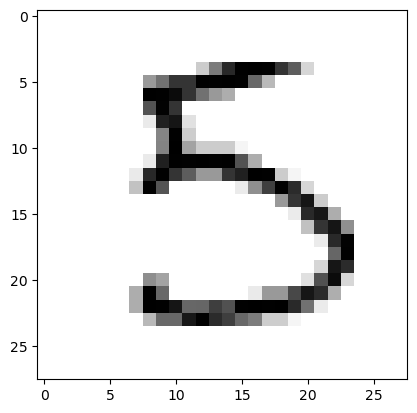

In [13]:
import matplotlib.pyplot as plt
# %matplotlib inline

fig = plt.figure
plt.imshow(x_test[15], cmap='gray_r')
plt.show()

### Build prediction URL for inference

In [14]:
predict_url = inference_url + ":predict"
predict_url

'https://digitrec-serve-predictor-ashish-kumarj-h-653cd6af.ingress.pcai.hpelabs.co.il/v1/models/digitrec-serve:predict'

### Build request for serving

In [15]:
image_data = np.expand_dims(x_test[15], axis=0)

In [16]:
instance = image_data.tolist() 

In [17]:
data = { "instances":  instance    }

### Send inference  request

In [19]:
response = requests.post(predict_url, json=data,verify=False)
response

/opt/conda/lib/python3.11/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'digitrec-serve-predictor-ashish-kumarj-h-653cd6af.ingress.pcai.hpelabs.co.il'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


<Response [200]>

### Get inference response

In [20]:
json_resp = response.json()
json_resp

{'predictions': [[1.38901228e-07,
   7.43089277e-06,
   5.09532647e-08,
   0.00244341418,
   1.46633772e-08,
   0.99747926,
   1.30586977e-05,
   7.92730475e-07,
   1.01309588e-05,
   4.57244059e-05]]}

In [21]:
max_conf = max(json_resp['predictions'][0])
print(f"Digit recognized: {json_resp['predictions'][0].index(max_conf)}\nConfidence: {max_conf}")

Digit recognized: 5
Confidence: 0.99747926


## Stop Kserve inference 

In [9]:
!kubectl delete inferenceservice {model_name}

inferenceservice.serving.kserve.io "digitrec-serve" deleted
